# Neurodesk for Multiple Sclerosis

**Author:** micmas (Neurodesk MS Workshop)

**Date:** June 2026

**License:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)

**Note:** This notebook uses neuroimaging tools from Neurocontainers. Those tools keep their original licenses — see the [Neurodesk citation guidelines](https://neurodesk.org/overview/how-to-cite-us/).

---

This notebook runs a small Multiple Sclerosis (MS) imaging pipeline from start to finish inside Neurodesk. It loads the tools, downloads an open MS dataset, and walks through the main analyses one step at a time. Run the cells from top to bottom.

You can run it in [Neurodesk Play](https://play.neurodesk.org/) (in your browser, nothing to install) or in any other Neurodesk environment.

## Citation and Resources

**Tools used**
- FSL (SIENA, FLIRT): Smith et al., NeuroImage 2004; Jenkinson et al., NeuroImage 2012.
- FreeSurfer (SAMSEG): Puonti, Iglesias & Van Leemput, NeuroImage 2016.
- LST-AI: Wiltgen et al., NeuroImage: Clinical 2024.
- Spinal Cord Toolbox (SCT): De Leener et al., NeuroImage 2017.
- Neurodesk: Renton, Dao, Johnstone et al., Nature Methods 2024.

**Dataset**
- open_ms_data (Ljubljana 3D MS lesion benchmark): Lesjak et al., Neuroinformatics 2018. https://github.com/muschellij2/open_ms_data

## Table of contents
[1. Load the tools](#1.-Load-the-tools)  
[2. Get the data](#2.-Get-the-data)  
[3. Look at the data](#3.-Look-at-the-data)  
[4. Lesion segmentation](#4.-Lesion-segmentation-with-SAMSEG)  
[5. Brain atrophy](#5.-Brain-atrophy-with-SIENA)  
[6. Going further](#6.-Going-further:-spinal-cord-and-quantitative-MRI)

## 1. Load the tools

Neurodesk provides each neuroimaging package as a module. `module.load()` makes a tool available inside this notebook, so the cells below (including `!shell` commands) can use it. Here we load FSL and FreeSurfer.

In [1]:
# Load the neuroimaging tools we need into this notebook.
import module
await module.load('fsl/6.0.7.22')
await module.load('freesurfer/8.2.0')
await module.list()

['fsl/6.0.7.22', 'freesurfer/8.2.0']

In [2]:
# FSL output format + the Python imaging stack
import os
os.environ['FSLOUTPUTTYPE'] = 'NIFTI_GZ'

# Install any Python packages the kernel is missing (nilearn is often not preinstalled)
import sys, subprocess, importlib
for pkg in ['nibabel', 'nilearn', 'pandas']:
    if importlib.util.find_spec(pkg) is None:
        print('installing', pkg, '...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

import nibabel, numpy as np, matplotlib, nilearn
print('nibabel    ', nibabel.__version__)
print('numpy      ', np.__version__)
print('matplotlib ', matplotlib.__version__)
print('nilearn    ', nilearn.__version__)
%matplotlib inline

installing nilearn ...
nibabel     5.4.2
numpy       2.4.6
matplotlib  3.10.9
nilearn     0.13.1


In [3]:
# Confirm the command-line tools actually respond
!flirt -version
!run_samseg --help 2>&1 | head -1
!echo "FREESURFER_HOME=$FREESURFER_HOME"

FLIRT version 6.0
usage: run_samseg [-h] -o DIR -i FILE [FILE ...] [-m MODE [MODE ...]]
FREESURFER_HOME=/cvmfs/neurodesk.ardc.edu.au/containers/freesurfer_8.2.0_20260601/freesurfer_8.2.0_20260601.simg/opt/freesurfer-8.2.0


## 2. Get the data

We use an open MS dataset. It has a cross-sectional set (one scan per patient, with an expert lesion mask) and a longitudinal set (two timepoints per patient) — enough for the lesion and atrophy analyses. The download is a few hundred MB and runs once.

In [4]:
from pathlib import Path

WORK = Path('/neurodesktop-storage/ms-workshop'); WORK.mkdir(parents=True, exist_ok=True)
DATA = WORK / 'open_ms_data'

if not DATA.exists():
    !cd {WORK} && git clone --depth 1 https://github.com/muschellij2/open_ms_data.git
else:
    print('Already present:', DATA)
!ls {DATA}

Already present: /neurodesktop-storage/ms-workshop/open_ms_data
README.Rmd	 cs_coreg.rda  long_coreg.rda  longitudinal	   programs
README.md	 cs_demog.rda  long_demog.rda  makefile
cross_sectional  cs_raw.rda    long_raw.rda    open_ms_data.Rproj


In [5]:
# Locate the files robustly, without hard-coding deep paths.
def pick_dir(*candidates):
    for c in candidates:
        if Path(c).is_dir():
            return Path(c)
    return None

def grab(folder, *keys):
    """First .nii.gz in `folder` whose name contains all `keys` (case-insensitive)."""
    for f in sorted(Path(folder).glob('*.nii.gz')):
        n = f.name.lower()
        if all(k in n for k in keys):
            return f
    return None

cs = DATA / 'cross_sectional'
cs_root = pick_dir(cs/'coregistered_resampled', cs/'coregistered', cs)   # prefer smaller resampled
patients = sorted(p for p in cs_root.iterdir() if p.is_dir())
print(f'{len(patients)} cross-sectional patients under {cs_root.name}/')

subj = patients[0]
print('Using subject:', subj.name)
print('Files:', [f.name for f in sorted(subj.glob("*.nii.gz"))])

FLAIR = grab(subj, 'flair')
T1    = grab(subj, 't1')
GT    = (grab(subj, 'consensus') or grab(subj, 'gold') or
         grab(subj, 'lesion') or grab(subj, 'gt') or grab(subj, 'mask'))
for label, f in [('FLAIR', FLAIR), ('T1', T1), ('lesion GT', GT)]:
    print(f'{label:10}: {f}')
assert FLAIR and T1, 'FLAIR/T1 not found — check the printed file list and adjust grab() keys.' 

30 cross-sectional patients under coregistered_resampled/
Using subject: patient01
Files: ['FLAIR.nii.gz', 'T1W.nii.gz', 'T1WKS.nii.gz', 'T2W.nii.gz', 'brainmask.nii.gz', 'consensus_gt.nii.gz']
FLAIR     : /neurodesktop-storage/ms-workshop/open_ms_data/cross_sectional/coregistered_resampled/patient01/FLAIR.nii.gz
T1        : /neurodesktop-storage/ms-workshop/open_ms_data/cross_sectional/coregistered_resampled/patient01/T1W.nii.gz
lesion GT : /neurodesktop-storage/ms-workshop/open_ms_data/cross_sectional/coregistered_resampled/patient01/consensus_gt.nii.gz


## 3. Look at the data

MS lesions are bright on FLAIR and darker on T1. Let's view the T1, the FLAIR, and the expert lesion mask for one patient.

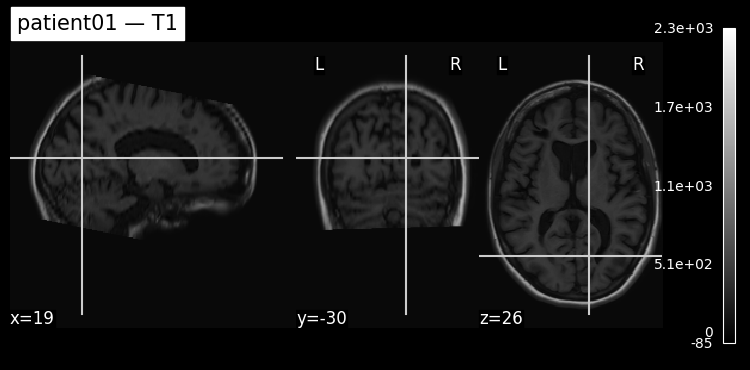

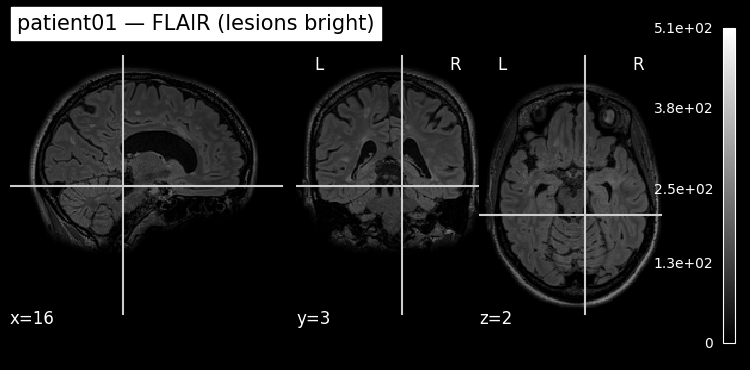

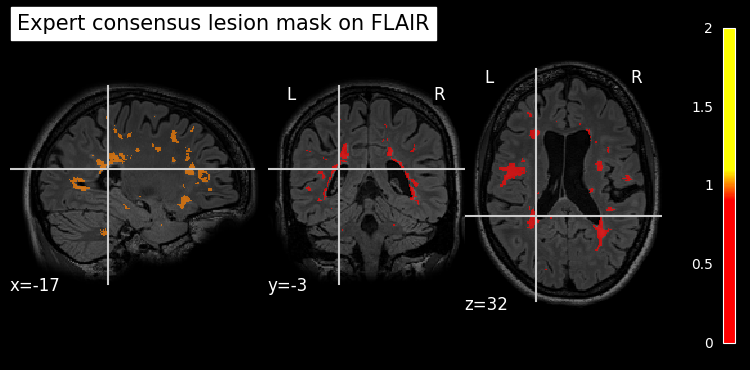

In [6]:
from nilearn import plotting

plotting.plot_anat(str(T1),    title=f'{subj.name} — T1')
plotting.plot_anat(str(FLAIR), title=f'{subj.name} — FLAIR (lesions bright)')
if GT:
    plotting.plot_roi(str(GT), bg_img=str(FLAIR),
                      title='Expert consensus lesion mask on FLAIR', cmap='autumn')
plotting.show()

## 4. Lesion segmentation with SAMSEG

SAMSEG (FreeSurfer) segments brain structures and white-matter lesions from any mix of contrasts — no training or GPU needed. We give it the T1 and the FLAIR. This takes about 10–20 minutes.

In [7]:
SAMSEG = WORK / 'out' / subj.name / 'samseg'
SAMSEG.mkdir(parents=True, exist_ok=True)

!run_samseg --input {T1} {FLAIR} --lesion --lesion-mask-pattern 0 1 --threads 4 --output {SAMSEG}

Read mesh collection: /usr/local/freesurfer/8.2.0/python/lib/python3.8/site-packages/samseg/atlas/20Subjects_smoothing2_down2_smoothingForAffine2/atlas_level1.txt.gz
Wrote mesh collection: /neurodesktop-storage/ms-workshop/out/patient01/samseg/lesion_atlas/atlas_level1.txt
Read mesh collection: /usr/local/freesurfer/8.2.0/python/lib/python3.8/site-packages/samseg/atlas/20Subjects_smoothing2_down2_smoothingForAffine2/atlas_level2.txt.gz
Wrote mesh collection: /neurodesktop-storage/ms-workshop/out/patient01/samseg/lesion_atlas/atlas_level2.txt
2026-06-09 14:49:12.792467: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 14:49:34.867214: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-09 14:49:46.85

In [8]:
# Total lesion volume is reported in samseg.stats
stats_file = SAMSEG / 'samseg.stats'
if stats_file.exists():
    for line in stats_file.read_text().splitlines():
        if 'lesion' in line.lower():
            print(line)
else:
    print('samseg.stats not found — did SAMSEG finish? Check the cell output above.')

# Measure Lesions, 12823.523689, mm^3


In [9]:
# Pull out the lesion label (SAMSEG uses 99) and score it against the expert mask
!mri_binarize --i {SAMSEG}/seg.mgz --match 99 --o {SAMSEG}/lesions.nii.gz

import nibabel as nib, numpy as np
from nilearn.image import resample_to_img

pred = nib.load(str(SAMSEG / 'lesions.nii.gz'))
pred_d = pred.get_fdata() > 0
print('SAMSEG lesion voxels:', int(pred_d.sum()))

if GT:
    gt = resample_to_img(str(GT), pred, interpolation='nearest')  # match SAMSEG space
    gt_d = gt.get_fdata() > 0
    inter = np.logical_and(pred_d, gt_d).sum()
    denom = pred_d.sum() + gt_d.sum()
    dice = (2.0 * inter / denom) if denom else float('nan')
    print(f'Dice vs expert consensus mask: {dice:.3f}')


8.2.0
cwd /home/jovyan/neurodesktop-storage/neurodesk-ms-workshop/workflows
cmdline /opt/freesurfer-8.2.0/bin/mri_binarize --i /neurodesktop-storage/ms-workshop/out/patient01/samseg/seg.mgz --match 99 --o /neurodesktop-storage/ms-workshop/out/patient01/samseg/lesions.nii.gz 
sysname  Linux
hostname jupyter-micmas
machine  x86_64
user     jovyan

input      /neurodesktop-storage/ms-workshop/out/patient01/samseg/seg.mgz
frame      0
nErode3d   0
nErode2d   0
output     /neurodesktop-storage/ms-workshop/out/patient01/samseg/lesions.nii.gz
Binarizing based on matching values
nMatch 1
 0    99
binval        1
binvalnot     0
fstart = 0, fend = 0, nframes = 1
Found 13779 values in range
Counting number of voxels in first frame
Found 13779 voxels in final mask
Writing output to /neurodesktop-storage/ms-workshop/out/patient01/samseg/lesions.nii.gz
Count: 13779 13779.000000 8870400 0.155337
mri_binarize done
SAMSEG lesion voxels: 13779


/tmp/ipykernel_1504/2501280430.py:12: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  gt = resample_to_img(str(GT), pred, interpolation='nearest')  # match SAMSEG space


Dice vs expert consensus mask: 0.498


In [ ]:
plotting.plot_roi(str(SAMSEG / 'lesions.nii.gz'), bg_img=str(FLAIR),
                  title='SAMSEG lesion segmentation on FLAIR', cmap='autumn')
plotting.show()

### Compare with LST-AI

LST-AI is a deep-learning tool trained on MS data. It segments lesions from T1 + FLAIR and also labels them by brain region. Neurodesk provides it as the `lstai` module. On a CPU it takes roughly 15–40 minutes (it skull-strips with HD-BET and runs three networks) and downloads its model weights on the first run.

In [ ]:
# Load LST-AI (deep-learning MS lesion segmentation).
import module
await module.load('lstai/1.2.0')

# Quick check that the command is available.
!lst --help 2>&1 | head -5

In [ ]:
# Run LST-AI on the same subject (T1 + FLAIR). Default mode = segmentation + region annotation.
# Model weights download automatically on first run (needs internet).
LSTOUT = WORK / 'out' / subj.name / 'lst_ai'
LSTTMP = WORK / 'out' / subj.name / 'lst_ai_tmp'
LSTOUT.mkdir(parents=True, exist_ok=True); LSTTMP.mkdir(parents=True, exist_ok=True)

# Images here are NOT skull-stripped, so we let LST-AI run HD-BET (default).
# If YOUR inputs are already brain-extracted, add  --stripped  to the command below.
!lst --t1 {T1} --flair {FLAIR} --output {LSTOUT} --temp {LSTTMP} --device cpu

print('\nLST-AI output files:')
for f in sorted(LSTOUT.iterdir()):
    print(' ', f.name)

In [ ]:
# Load the LST-AI lesion mask, report volume + Dice, and show its per-region annotation
import nibabel as nib, numpy as np
from nilearn.image import resample_to_img

def find(folder, *keys):
    for f in sorted(Path(folder).glob('*.nii.gz')):
        n = f.name.lower()
        if all(k in n for k in keys):
            return f
    return None

# binary segmentation in FLAIR space
lst_seg = find(LSTOUT, 'seg') or find(LSTOUT, 'lesion') or next(iter(sorted(LSTOUT.glob('*.nii.gz'))), None)
print('LST-AI segmentation:', lst_seg)

lst_img = nib.load(str(lst_seg))
lst_d = lst_img.get_fdata() > 0
print('LST-AI lesion voxels:', int(lst_d.sum()))

if GT:
    gt_l = resample_to_img(str(GT), lst_img, interpolation='nearest').get_fdata() > 0
    inter = np.logical_and(lst_d, gt_l).sum(); denom = lst_d.sum() + gt_l.sum()
    dice_lst = (2.0*inter/denom) if denom else float('nan')
    print(f'Dice (LST-AI vs expert): {dice_lst:.3f}')

# Per-region lesion annotation, if produced
csv = next(iter(sorted(LSTOUT.glob('*.csv'))), None)
if csv:
    print('\nLesion statistics (', csv.name, '):')
    print(csv.read_text())

In [ ]:
# Side-by-side: expert mask vs SAMSEG vs LST-AI, all on FLAIR
from nilearn import plotting
import nibabel as nib
from nilearn.image import resample_to_img

flair_img = nib.load(str(FLAIR))
def on_flair(mask_path):
    return resample_to_img(str(mask_path), flair_img, interpolation='nearest')

if GT:
    plotting.plot_roi(str(GT), bg_img=str(FLAIR), title='Expert consensus', cmap='autumn')
plotting.plot_roi(on_flair(SAMSEG/'lesions.nii.gz'), bg_img=str(FLAIR), title='SAMSEG', cmap='autumn')
plotting.plot_roi(on_flair(lst_seg),                 bg_img=str(FLAIR), title='LST-AI', cmap='autumn')
plotting.show()

# Quick summary table
import numpy as np
rows = []
def vol(mask_img): return int((mask_img.get_fdata() > 0).sum())
gt_on = on_flair(GT) if GT else None
for name, m in [('SAMSEG', on_flair(SAMSEG/'lesions.nii.gz')), ('LST-AI', on_flair(lst_seg))]:
    md_ = m.get_fdata() > 0
    if gt_on is not None:
        g = gt_on.get_fdata() > 0
        d = 2*np.logical_and(md_, g).sum() / (md_.sum() + g.sum())
    else:
        d = float('nan')
    rows.append((name, int(md_.sum()), round(d, 3)))
print(f"\n{'method':10}{'lesion voxels':>15}{'Dice vs expert':>16}")
if gt_on is not None:
    print(f"{'EXPERT':10}{vol(gt_on):>15}{'1.000':>16}")
for name, v, d in rows:
    print(f"{name:10}{v:>15}{d:>16}")

### Clinical interpretation
- **Total lesion volume** is a standard MS biomarker, though it correlates only weakly with disability (the *clinico-radiological paradox*).
- **Lesion location** (periventricular, juxtacortical, infratentorial, spinal) carries diagnostic weight under the **McDonald 2017** criteria — note LST-AI annotates these automatically.
- **SAMSEG vs LST-AI:** SAMSEG is a generative atlas model (no MS training, very robust to protocol changes); LST-AI is a discriminative ensemble trained on MS data (often higher Dice in-domain, but more sensitive to acquisition shifts). Comparing them on your own data is the point of this section.
- **Dice ~0.6–0.7** vs a single rater is typical for automated MS tools — inter-rater Dice itself is rarely above ~0.8.

## 5. Brain atrophy with SIENA

SIENA (FSL) measures the percentage brain volume change (PBVC) between two timepoints — a common measure in MS. We run it on the two timepoints of one longitudinal subject. (For reference: healthy ageing is about -0.2%/year; MS is often -0.5 to -1.0%/year.)

In [ ]:
lg = DATA / 'longitudinal'
lg_root = pick_dir(lg/'coregistered_resampled', lg/'coregistered', lg)
lg_patients = sorted(p for p in lg_root.iterdir() if p.is_dir())
print(f'{len(lg_patients)} longitudinal patients under {lg_root.name}/')

lsubj = lg_patients[0]
studies = sorted(p for p in lsubj.iterdir() if p.is_dir())
print('Subject', lsubj.name, '— timepoints:', [s.name for s in studies])

# If timepoints are sub-folders, grab a T1 from each; otherwise look for two T1s in the patient folder.
if len(studies) >= 2:
    T1_tp1, T1_tp2 = grab(studies[0], 't1'), grab(studies[1], 't1')
else:
    t1s = sorted(lsubj.rglob('*[tT]1*.nii.gz'))
    T1_tp1, T1_tp2 = (t1s[0], t1s[1]) if len(t1s) >= 2 else (None, None)

print('TP1 T1:', T1_tp1)
print('TP2 T1:', T1_tp2)
assert T1_tp1 and T1_tp2, 'Could not find two T1 timepoints — inspect the longitudinal folder layout.' 

In [ ]:
SIENA = WORK / 'out' / lsubj.name / 'siena'
SIENA.mkdir(parents=True, exist_ok=True)

!siena {T1_tp1} {T1_tp2} -o {SIENA}

In [ ]:
report = SIENA / 'report.siena'
if report.exists():
    txt = report.read_text()
    print(txt)
    for line in txt.splitlines():
        if 'PBVC' in line:
            print('>>>', line.strip())
else:
    print('report.siena not found — check the SIENA output above (and report.html for QC).')

### Clinical interpretation
- **Annualised PBVC** is the headline atrophy metric in MS DMT trials.
- **Pseudoatrophy** early in treatment (resolving inflammatory oedema) can confound short intervals — prefer ≥ 12-month follow-up.
- Single-timepoint alternative: **SIENAX** (normalised brain volume). For regional/cortical detail: the **FreeSurfer longitudinal** stream.

## 6. Going further: spinal cord and quantitative MRI

The open dataset has no spinal cord or magnetisation-transfer data, so the two cells below only run if you add your own data at the paths shown. Both are important in MS.

In [ ]:
# --- Spinal cord cross-sectional area (CSA) with SCT ---
CORD_T2 = WORK / 'mydata' / 'cord_T2w.nii.gz'
if CORD_T2.exists():
    try:
        await module.load('spinalcordtoolbox')   # if this errors: await module.avail('spinal')
    except Exception as e:
        print('Adjust the SCT module name:', e)
    CORD_OUT = WORK / 'out' / 'cord'; CORD_OUT.mkdir(parents=True, exist_ok=True)
    # Newer SCT: `sct_deepseg spinalcord`; older SCT: `sct_deepseg_sc`
    !sct_deepseg_sc -i {CORD_T2} -c t2 -ofolder {CORD_OUT}
    SEG = CORD_OUT / (CORD_T2.stem.replace('.nii','') + '_seg.nii.gz')
    !sct_label_vertebrae -i {CORD_T2} -s {SEG} -c t2 -ofolder {CORD_OUT}
    !sct_process_segmentation -i {SEG} -vert 2:5 -perlevel 1 -o {CORD_OUT}/CSA.csv
    import pandas as pd; display(pd.read_csv(CORD_OUT/'CSA.csv'))
else:
    print('No cord scan found. Drop a cervical T2 at', CORD_T2, 'to run SCT.')
    print('Upper-cervical (C2–C3) CSA is the most replicated cord-atrophy biomarker in MS.')

In [ ]:
# --- Magnetisation Transfer Ratio (MTR): a myelin-sensitive qMRI metric ---
QDIR = WORK / 'mydata' / 'qmri'
mt_on, mt_off = QDIR / 'MTon.nii.gz', QDIR / 'MToff.nii.gz'
if mt_on.exists() and mt_off.exists():
    import nibabel as nib, numpy as np
    on  = nib.load(str(mt_on)).get_fdata()
    off_img = nib.load(str(mt_off)); off = off_img.get_fdata()
    with np.errstate(divide='ignore', invalid='ignore'):
        mtr = np.where(off > 0, 100.0 * (off - on) / off, 0.0)
    QDIR.mkdir(parents=True, exist_ok=True)
    nib.save(nib.Nifti1Image(mtr, off_img.affine, off_img.header), str(QDIR / 'MTR.nii.gz'))
    print('Saved MTR map. Healthy NAWM MTR ~ 30-40%; lesional MTR drops 20-50% (demyelination).')
else:
    print('No MT data found. Add MTon.nii.gz / MToff.nii.gz under', QDIR, 'to compute MTR.')

## Wrap-up & reproducibility

You ran a full MS imaging mini-pipeline in one environment: **lesion segmentation**
scored against an expert mask, and **longitudinal atrophy** — plus hooks for cord and
qMRI work.

To make a run reproducible:
- **Pin the Neurodesk image tag** (e.g. `vnmd/neurodesktop:2026-04-01`, not `latest`).
- **Pin module versions** — replace `await module.load('fsl')` with the exact version you used (see `await module.list()`).
- Commit this notebook together with those version strings.

**Where to go next:** swap in your own (de-identified) T1+FLAIR, compare SAMSEG against LST or a deep-learning model, or extend the longitudinal analysis to SIENAX / FreeSurfer-longitudinal.